# Market-Basket Analysis on the IMDB Top 1000 dataset

Implementation of A-Priori and PCY to find frequent itemsets of actors,
with a scalability analysis based on basket replication.

In [57]:
!pip -q install kaggle pandas numpy matplotlib

In [58]:
import os
import zipfile
import time
import random
from itertools import combinations
from collections import defaultdict, Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [59]:
# Insert your Kaggle credentials here.
# In the final version to submit, replace these with "xxxxxx" to avoid sharing sensitive data.
os.environ["KAGGLE_USERNAME"] = "xxxxxx"
os.environ["KAGGLE_KEY"] = "xxxxxx"

In [60]:
# Global variables to control execution

USE_SAMPLE = False        # True to work on a subset of the movies
SAMPLE_SIZE = 600         # subset size (when USE_SAMPLE = True)
RANDOM_STATE = 42         # for reproducible results

MIN_SUPPORT = 0.003       # relative support threshold (same for all levels)

STAR_COLUMNS = ["Star1", "Star2", "Star3", "Star4"]

# Levels for the scalability analysis (target number of baskets)
SCALING_LEVELS = [10_000, 50_000, 100_000, 200_000]
N_REPEATS = 7             # repetitions for each timing measurement

## 1. Data loading

We download the IMDB Top 1000 dataset from Kaggle and load it into a DataFrame.

In [61]:
!kaggle datasets download -d harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows

Dataset URL: https://www.kaggle.com/datasets/harshitshankhdhar/imdb-dataset-of-top-1000-movies-and-tv-shows
License(s): CC0-1.0
imdb-dataset-of-top-1000-movies-and-tv-shows.zip: Skipping, found more recently modified local copy (use --force to force download)


In [62]:
with zipfile.ZipFile("imdb-dataset-of-top-1000-movies-and-tv-shows.zip", "r") as zip_ref:
    zip_ref.extractall()

In [63]:
df = pd.read_csv("imdb_top_1000.csv")

print("Shape:", df.shape)
print("Columns:", list(df.columns))
df.head()

Shape: (1000, 16)
Columns: ['Poster_Link', 'Series_Title', 'Released_Year', 'Certificate', 'Runtime', 'Genre', 'IMDB_Rating', 'Overview', 'Meta_score', 'Director', 'Star1', 'Star2', 'Star3', 'Star4', 'No_of_Votes', 'Gross']


,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [64]:
# Look at the columns we care about and check for missing values
print("Null counts in star columns:")
print(df[STAR_COLUMNS].isnull().sum())

df[["Series_Title"] + STAR_COLUMNS].head(10)

Null counts in star columns:
Star1    0
Star2    0
Star3    0
Star4    0
dtype: int64


,Series_Title,Star1,Star2,Star3,Star4
0,The Shawshank Redemption,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler
1,The Godfather,Marlon Brando,Al Pacino,James Caan,Diane Keaton
2,The Dark Knight,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine
3,The Godfather: Part II,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton
4,12 Angry Men,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler
5,The Lord of the Rings: The Return of the King,Elijah Wood,Viggo Mortensen,Ian McKellen,Orlando Bloom
6,Pulp Fiction,John Travolta,Uma Thurman,Samuel L. Jackson,Bruce Willis
7,Schindler's List,Liam Neeson,Ralph Fiennes,Ben Kingsley,Caroline Goodall
8,Inception,Leonardo DiCaprio,Joseph Gordon-Levitt,Elliot Page,Ken Watanabe
9,Fight Club,Brad Pitt,Edward Norton,Meat Loaf,Zach Grenier


## 2. Preprocessing: building the baskets

Each movie becomes a *basket*, and the actors in the Star1-Star4 columns are the *items*.
We clean the actor names (trim whitespace, drop missing or empty values) and turn each
movie into a set of actors. Using a set automatically removes any duplicate actor within
the same movie.

In [65]:
def normalize_actor(value):
    # Return a cleaned actor name, or None if the value is missing/empty.
    if value is None:
        return None
    if isinstance(value, float) and np.isnan(value):
        return None

    name = str(value).strip()
    if name == "" or name.lower() == "nan":
        return None
    return name

In [66]:
def row_to_basket(row):
    # Turn one movie row into a set of cleaned actor names.
    actors = set()
    for col in STAR_COLUMNS:
        actor = normalize_actor(row[col])
        if actor is not None:
            actors.add(actor)
    return actors

In [67]:
working_df = df.copy()  # keep the original DataFrame untouched

if USE_SAMPLE:
    working_df = working_df.sample(
        n=min(SAMPLE_SIZE, len(working_df)),
        random_state=RANDOM_STATE,
    ).reset_index(drop=True)
else:
    working_df = working_df.reset_index(drop=True)

print("Movies used:", len(working_df))

Movies used: 1000


In [68]:
baskets = []
for _, row in working_df.iterrows():
    basket = row_to_basket(row)
    if basket:  # keep only non-empty baskets
        baskets.append(basket)

print("Number of baskets:", len(baskets))

Number of baskets: 1000


In [69]:
distinct_items = set().union(*baskets)

print("Number of baskets:", len(baskets))
print("Distinct actors:", len(distinct_items))
print("Example baskets:")
for b in baskets[:5]:
    print(" ", b)

Number of baskets: 1000
Distinct actors: 2709
Example baskets:
  {'Tim Robbins', 'Morgan Freeman', 'Bob Gunton', 'William Sadler'}
  {'Al Pacino', 'James Caan', 'Diane Keaton', 'Marlon Brando'}
  {'Aaron Eckhart', 'Michael Caine', 'Heath Ledger', 'Christian Bale'}
  {'Al Pacino', 'Robert De Niro', 'Robert Duvall', 'Diane Keaton'}
  {'John Fiedler', 'Martin Balsam', 'Henry Fonda', 'Lee J. Cobb'}


## 3. The A-Priori algorithm

A-Priori finds frequent itemsets level by level. It relies on the *monotonicity*
property: an itemset can be frequent only if all of its subsets are frequent.

- **Pass 1**: count single items and keep the frequent ones.
- **Pass k**: build candidate itemsets of size k from the frequent itemsets of size
  k-1, then count them and keep the frequent ones.

The support threshold is given as a relative frequency and converted into an absolute
count based on the number of baskets.

In [70]:
def get_frequent_singletons(baskets, min_count):
    # Pass 1: count individual items and keep those reaching min_count.
    counts = Counter()
    for basket in baskets:
        for item in basket:
            counts[item] += 1

    frequent = {}
    for item, c in counts.items():
        if c >= min_count:
            frequent[frozenset([item])] = c
    return frequent

In [71]:
def generate_candidates(prev_frequent_sets, k):
    # Build candidate itemsets of size k by joining frequent itemsets of size k-1.
    # Two (k-1)-itemsets are joined only if they share their first k-2 items.
    prev = [sorted(s) for s in prev_frequent_sets]
    prev.sort()
    candidates = set()

    for i in range(len(prev)):
        for j in range(i + 1, len(prev)):
            a, b = prev[i], prev[j]
            if a[: k - 2] == b[: k - 2]:  # share the first k-2 items
                candidate = frozenset(a) | frozenset(b)
                if len(candidate) == k:
                    # prune: keep only if all (k-1)-subsets are frequent
                    if all(frozenset(s) in prev_frequent_sets
                           for s in combinations(candidate, k - 1)):
                        candidates.add(candidate)
            else:
                break  # since prev is sorted, no further match is possible
    return candidates

In [72]:
def count_candidates(baskets, candidates, k):
    # Count how many baskets contain each candidate itemset of size k.
    counts = Counter()
    for basket in baskets:
        if len(basket) < k:
            continue
        for candidate in combinations(sorted(basket), k):
            cand_set = frozenset(candidate)
            if cand_set in candidates:
                counts[cand_set] += 1
    return counts

In [73]:
def apriori(baskets, min_support, max_k=3):
    # Run A-Priori and return a dict {itemset: count} for all frequent itemsets.
    n_baskets = len(baskets)
    min_count = min_support * n_baskets

    frequent = {}
    current = get_frequent_singletons(baskets, min_count)
    frequent.update(current)

    k = 2
    while current and k <= max_k:
        candidates = generate_candidates(set(current.keys()), k)
        if not candidates:
            break

        counts = count_candidates(baskets, candidates, k)
        current = {s: c for s, c in counts.items() if c >= min_count}
        frequent.update(current)
        k += 1

    return frequent

In [74]:
min_count = MIN_SUPPORT * len(baskets)
print(f"Relative support: {MIN_SUPPORT}  ->  absolute count: {min_count}")

result = apriori(baskets, MIN_SUPPORT, max_k=3)

# Group results by itemset size
by_size = defaultdict(list)
for itemset, count in result.items():
    by_size[len(itemset)].append((itemset, count))

for size in sorted(by_size):
    print(f"\nFrequent itemsets of size {size}: {len(by_size[size])}")

Relative support: 0.003  ->  absolute count: 3.0

Frequent itemsets of size 1: 271

Frequent itemsets of size 2: 25

Frequent itemsets of size 3: 3


In [75]:
def show_itemsets(result, n_baskets, min_size=2):
    # Print frequent itemsets of size >= min_size, sorted by count.
    rows = []
    for itemset, count in result.items():
        if len(itemset) >= min_size:
            rows.append((count, count / n_baskets, sorted(itemset)))
    rows.sort(reverse=True)

    for count, support, items in rows:
        print(f"count={count:>3}  support={support:.4f}  {items}")

show_itemsets(result, len(baskets), min_size=2)

count=  6  support=0.0060  ['Daniel Radcliffe', 'Rupert Grint']
count=  5  support=0.0050  ['Emma Watson', 'Rupert Grint']
count=  5  support=0.0050  ['Daniel Radcliffe', 'Emma Watson', 'Rupert Grint']
count=  5  support=0.0050  ['Daniel Radcliffe', 'Emma Watson']
count=  4  support=0.0040  ['Tim Allen', 'Tom Hanks']
count=  4  support=0.0040  ['Joe Pesci', 'Robert De Niro']
count=  3  support=0.0030  ['Tatsuya Nakadai', 'Toshirô Mifune']
count=  3  support=0.0030  ['Takashi Shimura', 'Toshirô Mifune']
count=  3  support=0.0030  ['Mark Ruffalo', 'Robert Downey Jr.']
count=  3  support=0.0030  ['Joe Russo', 'Robert Downey Jr.']
count=  3  support=0.0030  ['Ian McKellen', 'Orlando Bloom']
count=  3  support=0.0030  ['Humphrey Bogart', 'Lauren Bacall']
count=  3  support=0.0030  ['Harrison Ford', 'Mark Hamill']
count=  3  support=0.0030  ['Ethan Hawke', 'Julie Delpy']
count=  3  support=0.0030  ['Ethan Coen', 'John Turturro']
count=  3  support=0.0030  ['Elijah Wood', 'Orlando Bloom']
cou

In [76]:
# Try several thresholds to pick a sensible one for the analysis.
for support in [0.005, 0.004, 0.003, 0.002]:
    res = apriori(baskets, support, max_k=3)
    sizes = Counter(len(s) for s in res)
    abs_count = support * len(baskets)
    print(f"support={support} (>= {abs_count:.0f} movies)  "
          f"size1={sizes[1]:>3}  size2={sizes[2]:>3}  size3={sizes[3]:>2}")

support=0.005 (>= 5 movies)  size1= 79  size2=  3  size3= 1
support=0.004 (>= 4 movies)  size1=145  size2=  5  size3= 1
support=0.003 (>= 3 movies)  size1=271  size2= 25  size3= 3
support=0.002 (>= 2 movies)  size1=641  size2=121  size3=25


In [77]:
# Chosen after exploring the thresholds above.
# 0.003 (at least 3 movies together) gives enough itemsets to analyze
# while keeping the criterion meaningful.
MIN_SUPPORT = 0.003

## 4. The PCY algorithm

PCY (Park-Chen-Yu) improves the second pass of A-Priori. During the first pass, while
counting single items, it also hashes every pair of items in each basket into a fixed
number of buckets and counts how many pairs fall into each bucket.

A pair can be frequent only if its bucket is frequent (reached the support threshold).
This gives an extra filter for pass 2: a candidate pair is kept only if both items are
frequent *and* the pair hashes to a frequent bucket. This discards many pairs before
counting them, reducing memory usage.

In [78]:
def pair_hash(item_a, item_b, n_buckets):
    # Map an unordered pair of items to a bucket index.
    # Sorting makes the hash independent of the order of the two items.
    first, second = sorted((item_a, item_b))
    return (hash(first) ^ hash(second)) % n_buckets

In [79]:
def pcy_first_pass(baskets, min_count, n_buckets):
    # Pass 1: count single items AND hash all pairs into buckets.
    item_counts = Counter()
    bucket_counts = np.zeros(n_buckets, dtype=np.int64)

    for basket in baskets:
        items = sorted(basket)
        for item in items:
            item_counts[item] += 1
        for a, b in combinations(items, 2):
            bucket_counts[pair_hash(a, b, n_buckets)] += 1

    # Frequent singletons
    frequent_items = {item for item, c in item_counts.items() if c >= min_count}

    # Bitmap: True if the bucket is frequent
    frequent_buckets = bucket_counts >= min_count

    return item_counts, frequent_items, frequent_buckets

In [80]:
def pcy_candidate_pairs(frequent_items, frequent_buckets, n_buckets):
    # Build candidate pairs: both items frequent AND the pair hashes to a frequent bucket.
    candidates = set()
    frequent_list = sorted(frequent_items)

    for a, b in combinations(frequent_list, 2):
        if frequent_buckets[pair_hash(a, b, n_buckets)]:
            candidates.add(frozenset((a, b)))
    return candidates

In [81]:
def pcy(baskets, min_support, n_buckets=10_000, max_k=3):
    # Run PCY and return a dict {itemset: count} for all frequent itemsets.
    n_baskets = len(baskets)
    min_count = min_support * n_baskets

    frequent = {}

    # Pass 1: items + bucket hashing
    item_counts, frequent_items, frequent_buckets = pcy_first_pass(
        baskets, min_count, n_buckets
    )
    for item in frequent_items:
        frequent[frozenset([item])] = item_counts[item]

    # Pass 2: count only the candidate pairs surviving the bucket filter
    candidate_pairs = pcy_candidate_pairs(frequent_items, frequent_buckets, n_buckets)
    pair_counts = count_candidates(baskets, candidate_pairs, 2)
    current = {s: c for s, c in pair_counts.items() if c >= min_count}
    frequent.update(current)

    # Pass 3+: from here on, behave like A-Priori (the bucket trick only helps pairs)
    k = 3
    while current and k <= max_k:
        candidates = generate_candidates(set(current.keys()), k)
        if not candidates:
            break
        counts = count_candidates(baskets, candidates, k)
        current = {s: c for s, c in counts.items() if c >= min_count}
        frequent.update(current)
        k += 1

    return frequent

In [82]:
res_apriori = apriori(baskets, MIN_SUPPORT, max_k=3)
res_pcy = pcy(baskets, MIN_SUPPORT, n_buckets=10_000, max_k=3)

print("A-Priori frequent itemsets:", len(res_apriori))
print("PCY frequent itemsets:     ", len(res_pcy))
print("Identical results:", res_apriori == res_pcy)

A-Priori frequent itemsets: 299
PCY frequent itemsets:      299
Identical results: True


## 5. Scalability analysis

To study how the algorithms scale with data size, we generate larger synthetic datasets
by replicating the original baskets. Pure replication multiplies the number of baskets
while preserving the relative support of every itemset: the frequent itemsets stay the
same, only their absolute counts grow. This lets us isolate the effect of data *volume*
on running time, independently of any change in the itemset structure.

In [83]:
def replicate_baskets(baskets, target_size):
    # Build a larger basket list by repeating the original baskets until target_size.
    # Pure replication: the relative support of every itemset is preserved.
    if target_size <= len(baskets):
        return list(baskets[:target_size])

    n_repeats = target_size // len(baskets)
    replicated = list(baskets) * n_repeats

    remainder = target_size - len(replicated)
    replicated.extend(baskets[:remainder])
    return replicated

In [84]:
# Build one dataset per level: the real 1000 baskets plus the scaled ones.
dataset_sizes = [len(baskets)] + SCALING_LEVELS  # [1000, 10000, 50000]

scaled_datasets = {}
for size in dataset_sizes:
    scaled_datasets[size] = replicate_baskets(baskets, size)
    print(f"Dataset with {size} baskets ready "
          f"(actual size: {len(scaled_datasets[size])})")

Dataset with 1000 baskets ready (actual size: 1000)
Dataset with 10000 baskets ready (actual size: 10000)
Dataset with 50000 baskets ready (actual size: 50000)
Dataset with 100000 baskets ready (actual size: 100000)
Dataset with 200000 baskets ready (actual size: 200000)


## 6. Timing experiment

We measure the running time of A-Priori and PCY on each dataset size. Each measurement
is repeated several times and we keep the minimum, which is the most stable estimate of
the actual computation cost (it is the run least affected by background activity on the
machine). Only the algorithm itself is timed; data loading and basket construction are
excluded.

In [85]:
def time_algorithm(algorithm, baskets, min_support, n_repeats, **kwargs):
    # Run the algorithm n_repeats times and return the minimum running time (seconds).
    times = []
    for _ in range(n_repeats):
        start = time.perf_counter()
        algorithm(baskets, min_support, **kwargs)
        times.append(time.perf_counter() - start)
    return min(times)

In [86]:
results_time = {"apriori": [], "pcy": []}

for size in dataset_sizes:
    data = scaled_datasets[size]

    t_apriori = time_algorithm(
        apriori, data, MIN_SUPPORT, N_REPEATS, max_k=3
    )
    t_pcy = time_algorithm(
        pcy, data, MIN_SUPPORT, N_REPEATS, n_buckets=10_000, max_k=3
    )

    results_time["apriori"].append(t_apriori)
    results_time["pcy"].append(t_pcy)

    print(f"size={size:>6}  "
          f"A-Priori={t_apriori:.3f}s  PCY={t_pcy:.3f}s")

size=  1000  A-Priori=0.095s  PCY=0.034s
size= 10000  A-Priori=0.153s  PCY=0.129s
size= 50000  A-Priori=0.366s  PCY=0.561s
size=100000  A-Priori=0.692s  PCY=1.128s
size=200000  A-Priori=1.241s  PCY=2.188s


## 7. How effective is the PCY bucket filter?

PCY only pays off if the bucket filter discards a meaningful fraction of candidate pairs.
Here we count how many candidate pairs survive the filter, compared to the number of
pairs A-Priori would have to count (all pairs of frequent items). If the two numbers are
close, the filter removes almost nothing and PCY cannot beat A-Priori.

In [87]:
def measure_pcy_filter(baskets, min_support, n_buckets=10_000):
    # Compare candidate pairs with and without the PCY bucket filter.
    n_baskets = len(baskets)
    min_count = min_support * n_baskets

    item_counts, frequent_items, frequent_buckets = pcy_first_pass(
        baskets, min_count, n_buckets
    )

    # A-Priori: every pair of frequent items is a candidate
    n_apriori_pairs = len(list(combinations(frequent_items, 2)))

    # PCY: only pairs whose bucket is frequent
    pcy_pairs = pcy_candidate_pairs(frequent_items, frequent_buckets, n_buckets)
    n_pcy_pairs = len(pcy_pairs)

    removed = n_apriori_pairs - n_pcy_pairs
    pct = 100 * removed / n_apriori_pairs if n_apriori_pairs else 0

    print(f"Frequent items:              {len(frequent_items)}")
    print(f"Candidate pairs (A-Priori):  {n_apriori_pairs}")
    print(f"Candidate pairs (PCY):       {n_pcy_pairs}")
    print(f"Pairs removed by filter:     {removed} ({pct:.1f}%)")


measure_pcy_filter(baskets, MIN_SUPPORT, n_buckets=10_000)

Frequent items:              271
Candidate pairs (A-Priori):  36585
Candidate pairs (PCY):       1067
Pairs removed by filter:     35518 (97.1%)


## 8. Results: running time comparison

We plot the running time of both algorithms against the number of baskets. The smallest
level (1000 baskets) is shown in the table but excluded from the plot, since at that
scale the running times are dominated by measurement noise.

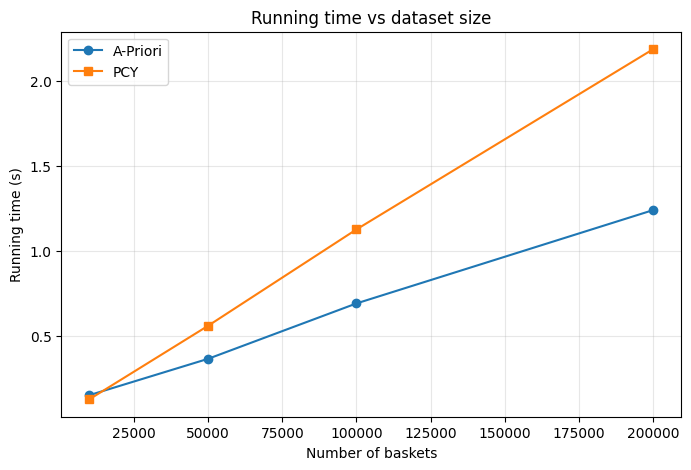

In [88]:
# Exclude the 1000-basket level from the plot (too noisy at that scale)
plot_sizes = [s for s in dataset_sizes if s >= 10_000]
plot_idx = [dataset_sizes.index(s) for s in plot_sizes]

apriori_plot = [results_time["apriori"][i] for i in plot_idx]
pcy_plot = [results_time["pcy"][i] for i in plot_idx]

plt.figure(figsize=(8, 5))
plt.plot(plot_sizes, apriori_plot, marker="o", label="A-Priori")
plt.plot(plot_sizes, pcy_plot, marker="s", label="PCY")

plt.xlabel("Number of baskets")
plt.ylabel("Running time (s)")
plt.title("Running time vs dataset size")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [89]:
summary = pd.DataFrame({
    "baskets": dataset_sizes,
    "apriori_time_s": results_time["apriori"],
    "pcy_time_s": results_time["pcy"],
})
summary["speedup_pcy"] = summary["apriori_time_s"] / summary["pcy_time_s"]
summary = summary.round(4)
summary

,baskets,apriori_time_s,pcy_time_s,speedup_pcy
0,1000,0.0949,0.0337,2.8179
1,10000,0.1527,0.1286,1.1873
2,50000,0.3664,0.5608,0.6533
3,100000,0.6923,1.1277,0.6139
4,200000,1.2413,2.1880,0.5673


## 9. Conclusions

We implemented and compared two market-basket algorithms, A-Priori and PCY, on the IMDB
Top 1000 dataset, treating each movie as a basket and its four lead actors as items.

**Frequent itemsets.** With a relative support of 0.003 (at least 3 movies), we found
271 frequent single actors, 25 frequent pairs and 3 frequent triples. The frequent
itemsets correspond to actors who repeatedly appear together, such as the lead trio of
the Harry Potter series.

**Correctness.** A-Priori and PCY return exactly the same frequent itemsets, confirming
that the PCY optimization does not change the result.

**Scalability.** Using pure replication of the baskets (up to 200,000), the running time
of both algorithms grows linearly with the number of baskets, confirming that the
approach scales with data volume.

**A-Priori vs PCY.** Although the PCY bucket filter removes 99.8% of the candidate pairs,
the absolute number of pairs counted by A-Priori is already very small, so the saving is
negligible. The extra cost of hashing every pair in the first pass, which grows with the
number of baskets, dominates: A-Priori is about twice as fast as PCY in this domain. PCY
pays off when the second pass is a genuine memory bottleneck (dense baskets, many
candidate pairs), which is not the case for baskets of only four actors.